In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import geopandas as gpd
from collections import Counter, defaultdict
import librosa
import soundfile as sf
from tqdm import tqdm

In [3]:
# Set paths
DATA_RAW = Path("/home/legionlinux/miniconda3/envs/torchenv/__INIT__/Kaggle/birdclef-2026/data/raw")
TRAIN_AUDIO_DIR = DATA_RAW / "train_audio"
TRAIN_SOUNDSCAPES_DIR = DATA_RAW / "train_soundscapes"

# Load all files

In [4]:
train = pd.read_csv(DATA_RAW / "train.csv")
trs = pd.read_csv(DATA_RAW / "train_soundscapes_labels.csv")
taxonomy = pd.read_csv(DATA_RAW / "taxonomy.csv")
ss = pd.read_csv(DATA_RAW / "sample_submission.csv")

# CSV Metadata Files Analysis

### `train.csv`

In [5]:
train

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35544,yeofly1,[],['call'],-6.7281,-76.4181,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,GABRIEL LEITE,by-nc-sa,4.0,https://xeno-canto.org/762473/download,yeofly1/XC762473.ogg,XC
35545,yeofly1,[],"['call', ' song']",-16.0538,-49.6040,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,JAYRSON ARAUJO DE OLIVEIRA,by-nc-sa,5.0,https://xeno-canto.org/818328/download,yeofly1/XC818328.ogg,XC
35546,yeofly1,[],['song'],5.9002,-74.8485,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,Jerome Fischer,by-nc-sa,4.0,https://xeno-canto.org/425545/download,yeofly1/XC425545.ogg,XC
35547,yeofly1,[],['song'],3.3821,-61.4464,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,GABRIEL LEITE,by-nc-sa,4.0,https://xeno-canto.org/456230/download,yeofly1/XC456230.ogg,XC


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35549 entries, 0 to 35548
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   primary_label     35549 non-null  object 
 1   secondary_labels  35549 non-null  object 
 2   type              35549 non-null  object 
 3   latitude          35549 non-null  float64
 4   longitude         35549 non-null  float64
 5   scientific_name   35549 non-null  object 
 6   common_name       35549 non-null  object 
 7   class_name        35549 non-null  object 
 8   inat_taxon_id     35549 non-null  int64  
 9   author            35549 non-null  object 
 10  license           35549 non-null  object 
 11  rating            35549 non-null  float64
 12  url               35549 non-null  object 
 13  filename          35549 non-null  object 
 14  collection        35549 non-null  object 
dtypes: float64(3), int64(1), object(11)
memory usage: 4.1+ MB


In [7]:
train_cat = train.select_dtypes(include=['object'])
train_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35549 entries, 0 to 35548
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   primary_label     35549 non-null  object
 1   secondary_labels  35549 non-null  object
 2   type              35549 non-null  object
 3   scientific_name   35549 non-null  object
 4   common_name       35549 non-null  object
 5   class_name        35549 non-null  object
 6   author            35549 non-null  object
 7   license           35549 non-null  object
 8   url               35549 non-null  object
 9   filename          35549 non-null  object
 10  collection        35549 non-null  object
dtypes: object(11)
memory usage: 3.0+ MB


In [8]:
train_num = train.select_dtypes(include=['int64', 'float64'])
train_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35549 entries, 0 to 35548
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   latitude       35549 non-null  float64
 1   longitude      35549 non-null  float64
 2   inat_taxon_id  35549 non-null  int64  
 3   rating         35549 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 1.1 MB


primary_label
116570       1
23150        1
516975       1
23724        1
209233       2
          ... 
houspa     496
soulap1    497
fepowl     497
banana     498
rubthr1    499
Name: count, Length: 206, dtype: int64


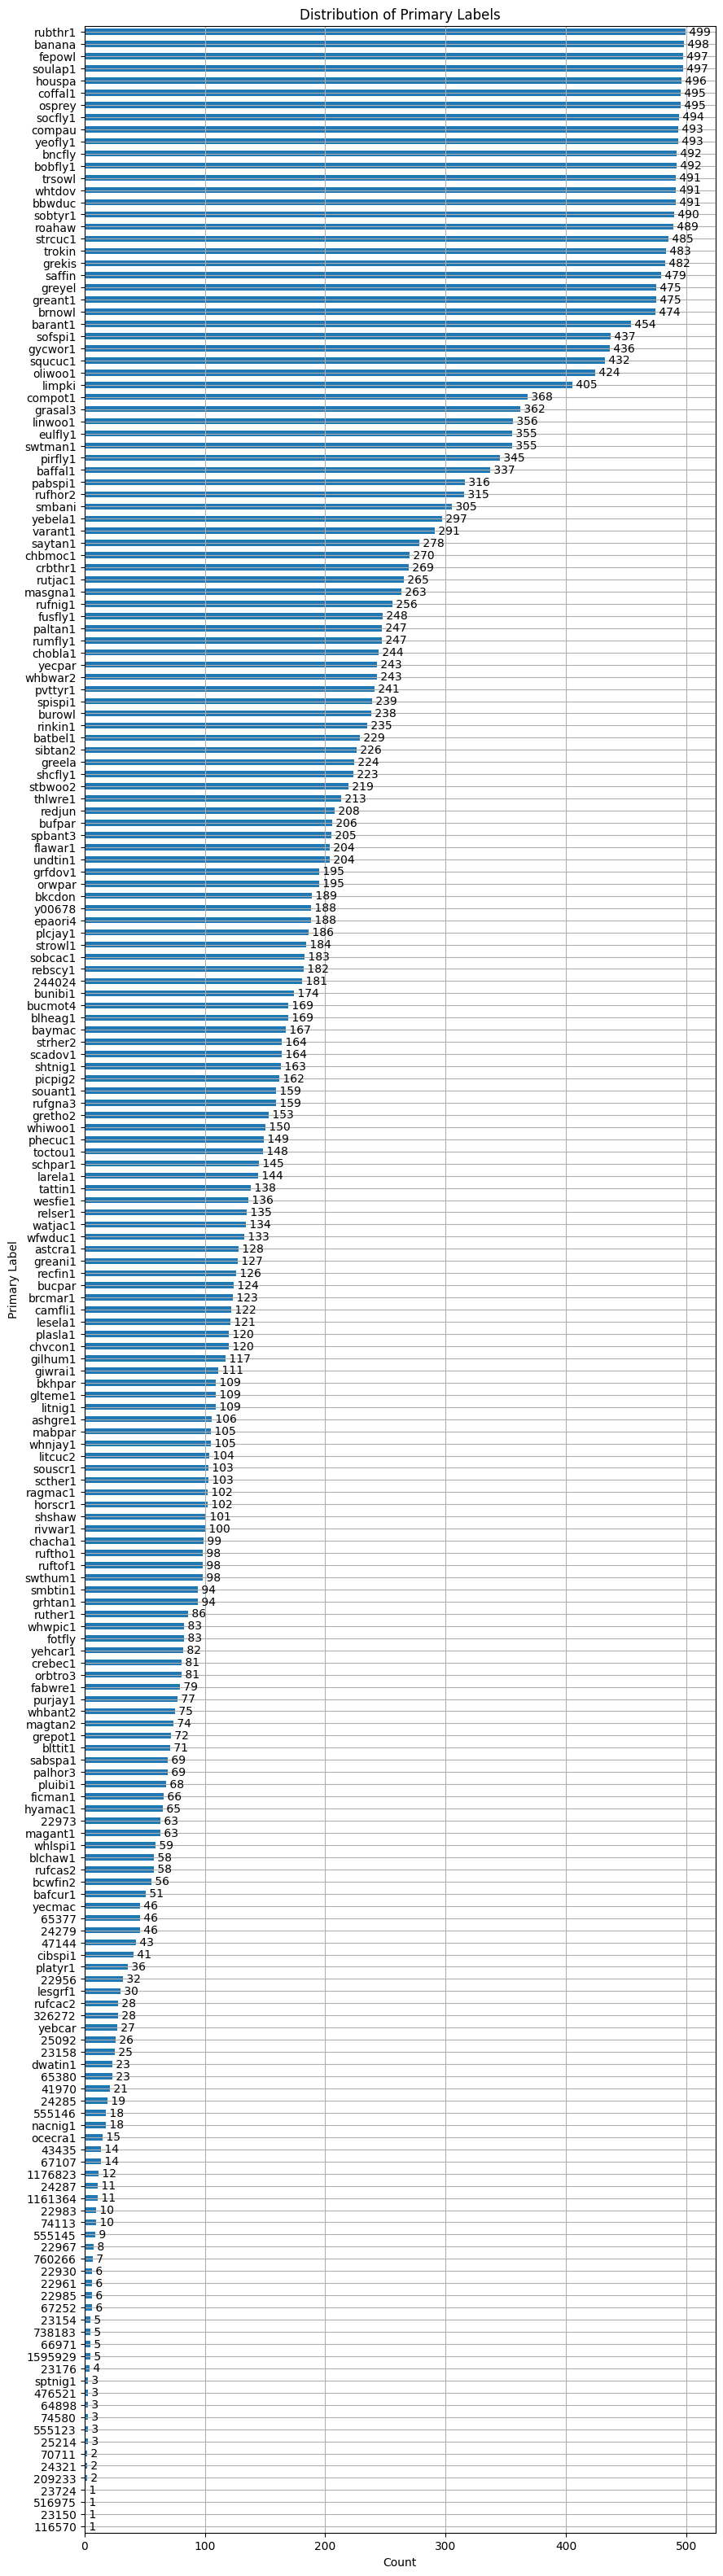

In [9]:
counts = train_cat['primary_label'].value_counts(ascending=True)

print(counts)

fig, ax = plt.subplots(figsize=(10, 40))

counts.plot(kind='barh', ax=ax)

# Put count at the front/end of each bar
for i, v in enumerate(counts.values):
    ax.text(
        v,            # end of bar
        i,            # bar position
        f' {v}',      # count text
        va='center',
        ha='left'
    )

ax.set_xlabel('Count')
ax.set_ylabel('Primary Label')
ax.set_title('Distribution of Primary Labels')

plt.grid(True)
plt.show()

In [10]:
train_cat[['primary_label', 'secondary_labels']].value_counts()

primary_label  secondary_labels              
houspa         []                                494
osprey         []                                493
compau         []                                474
soulap1        []                                470
brnowl         []                                470
                                                ... 
linwoo1        ['orwpar', 'saffin', 'yecpar']      1
               ['masgna1']                         1
               ['lesela1']                         1
               ['grfdov1']                         1
limpki         ['undtin1']                         1
Name: count, Length: 3762, dtype: int64

In [11]:
train_cat[['primary_label', 'secondary_labels', 'type']].value_counts()

primary_label  secondary_labels                                        type                     
houspa         []                                                      []                           386
osprey         []                                                      []                           376
brnowl         []                                                      []                           357
greyel         []                                                      []                           312
grekis         []                                                      []                           305
                                                                                                   ... 
yeofly1        ['whtdov']                                              ['call']                       1
               ['whtdov', 'soulap1', 'grekis']                         ['song']                       1
               ['whtdov', 'plasla1']                                   

In [12]:
train_cat['type'].value_counts()

type
[]                               12975
['song']                         10376
['call']                          6205
['call', ' song']                 1458
['flight call']                    711
                                 ...  
['song', ' 2 song types']            1
['call', ' call variation']          1
['song', ' human voice']             1
['call', ' single call note']        1
['call', ' calls (2 types)']         1
Name: count, Length: 755, dtype: int64

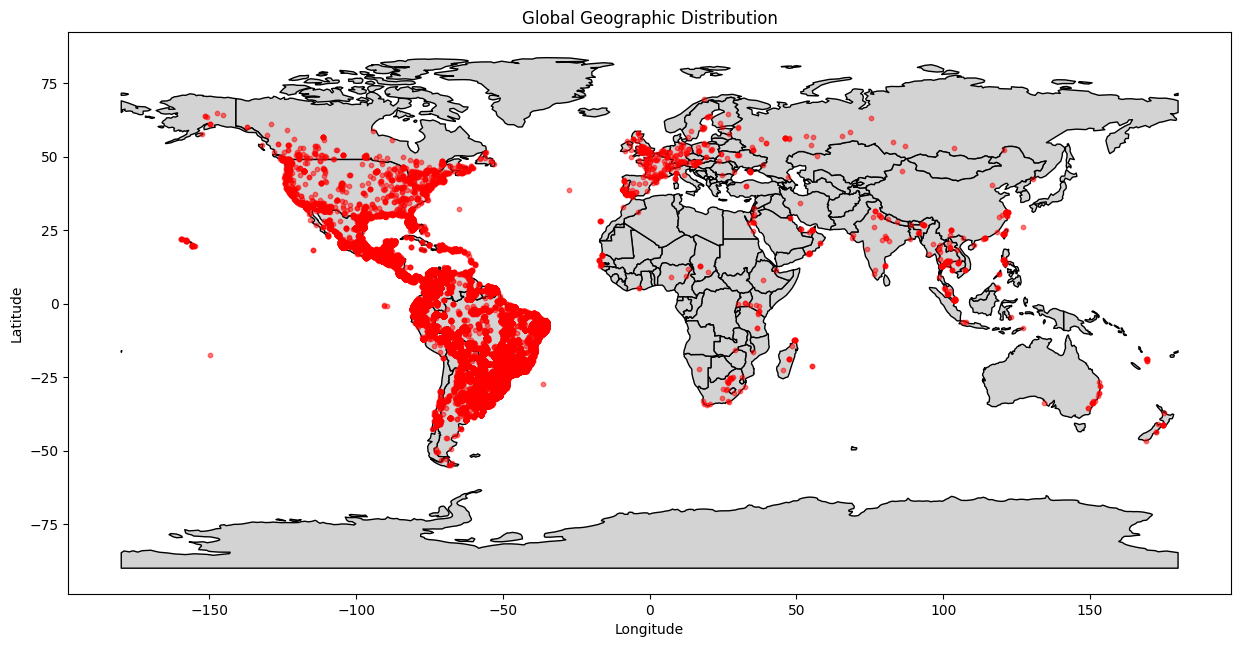

In [13]:
# Load world map from Natural Earth
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# Create figure
fig, ax = plt.subplots(figsize=(15, 10))

# Plot world map
world.plot(
    ax=ax,
    color='lightgray',
    edgecolor='black'
)

# Plot latitude/longitude points
ax.scatter(
    train_num['longitude'],
    train_num['latitude'],
    s=10,
    color='red',
    alpha=0.5
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Global Geographic Distribution")

plt.show()

In [14]:
train_cat[['scientific_name', 'common_name', 'class_name']].value_counts()

scientific_name             common_name                 class_name
Turdus rufiventris          Rufous-bellied Thrush       Aves          499
Coereba flaveola            Bananaquit                  Aves          498
Glaucidium brasilianum      Ferruginous Pygmy Owl       Aves          497
Vanellus chilensis          Southern Lapwing            Aves          497
Passer domesticus           House Sparrow               Aves          496
                                                                     ... 
Leptodactylus macrosternum  Cei's White-lipped Frog     Amphibia        2
Caiman yacare               Southern Spectacled Caiman  Reptilia        1
Phyllomedusa sauvagii       Waxy Monkey Tree Frog       Amphibia        1
Sapajus cay                 Hooded Capuchin             Mammalia        1
Physalaemus centralis       Central Dwarf Frog          Amphibia        1
Name: count, Length: 206, dtype: int64

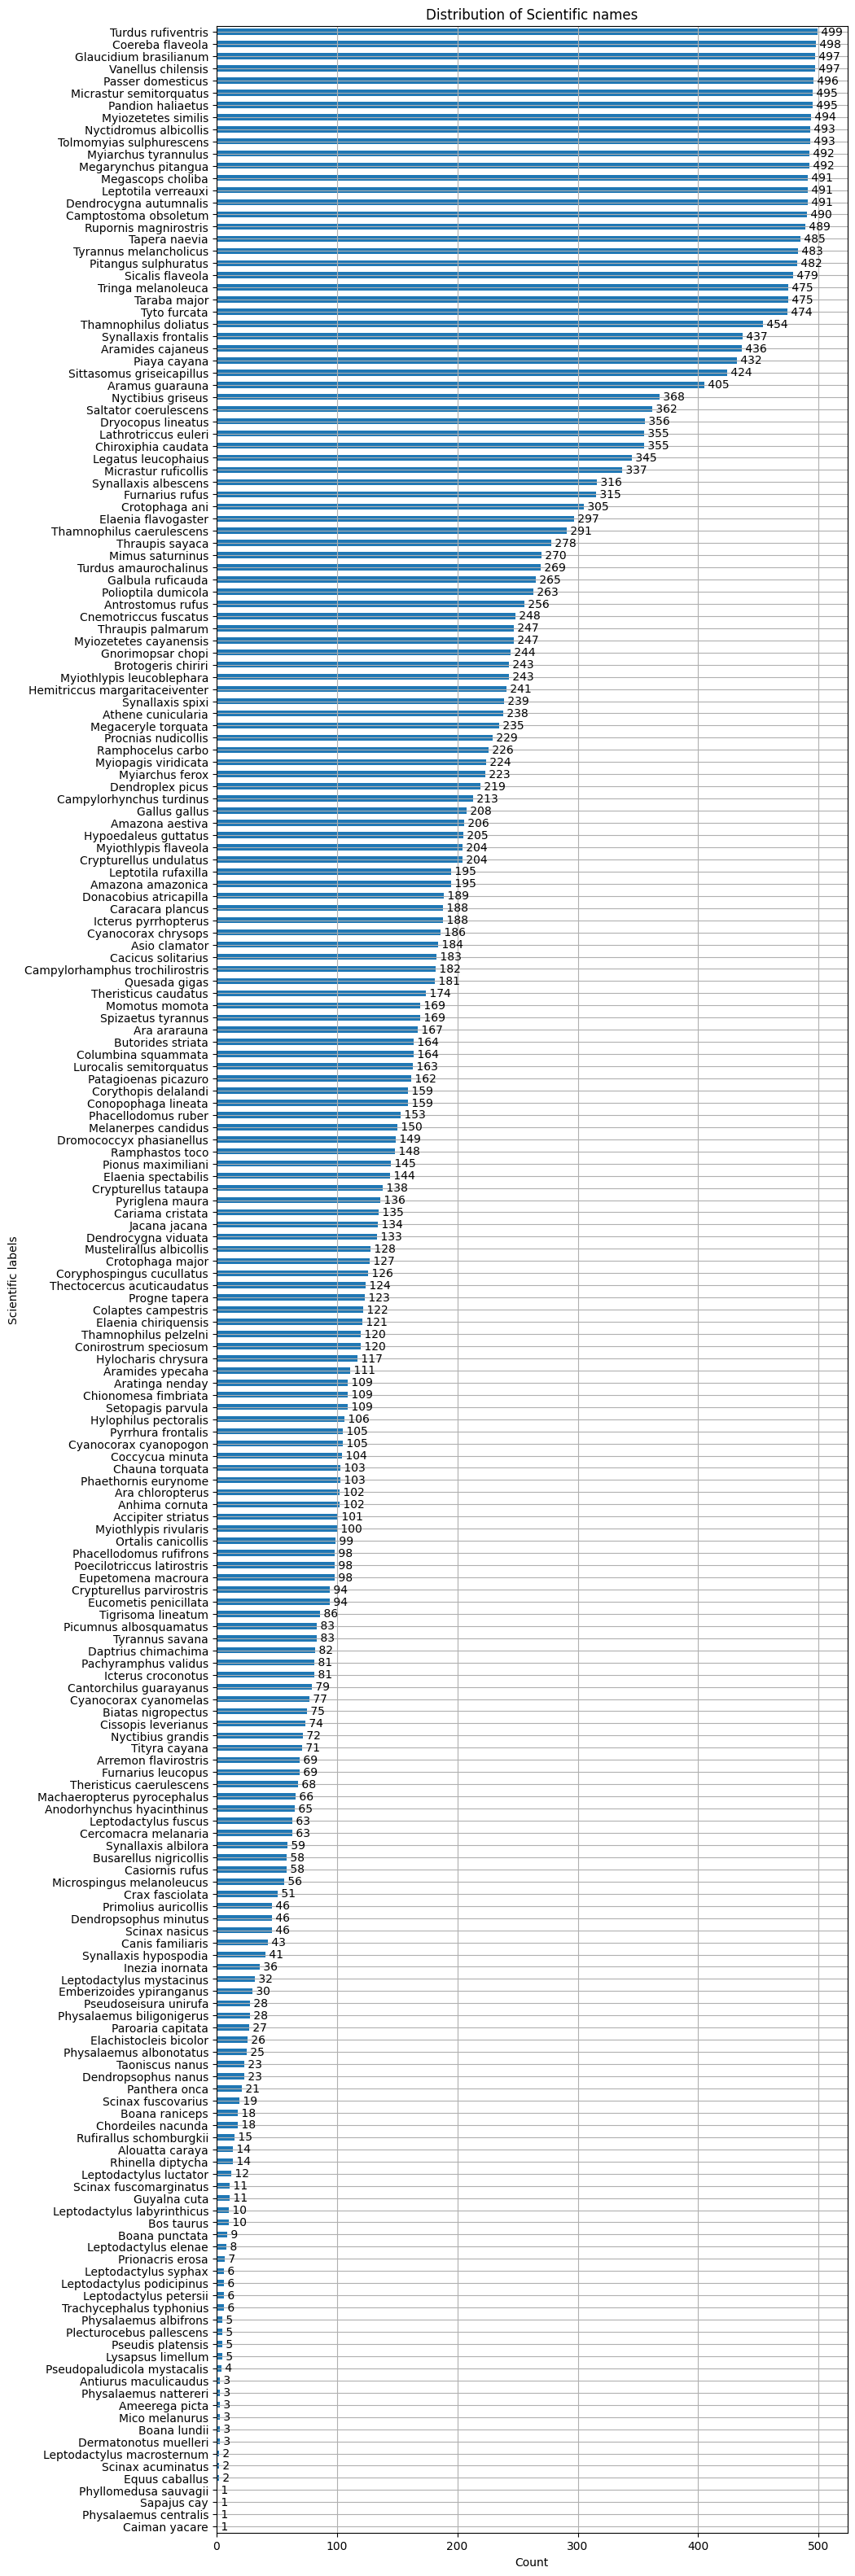

In [15]:
counts = train_cat['scientific_name'].value_counts(ascending=True)

fig, ax = plt.subplots(figsize=(10, 40))

counts.plot(kind='barh', ax=ax)

# Put count at the front/end of each bar
for i, v in enumerate(counts.values):
    ax.text(
        v,            # end of bar
        i,            # bar position
        f' {v}',      # count text
        va='center',
        ha='left'
    )

ax.set_xlabel('Count')
ax.set_ylabel('Scientific labels')
ax.set_title('Distribution of Scientific names')

plt.grid(True)
plt.show()

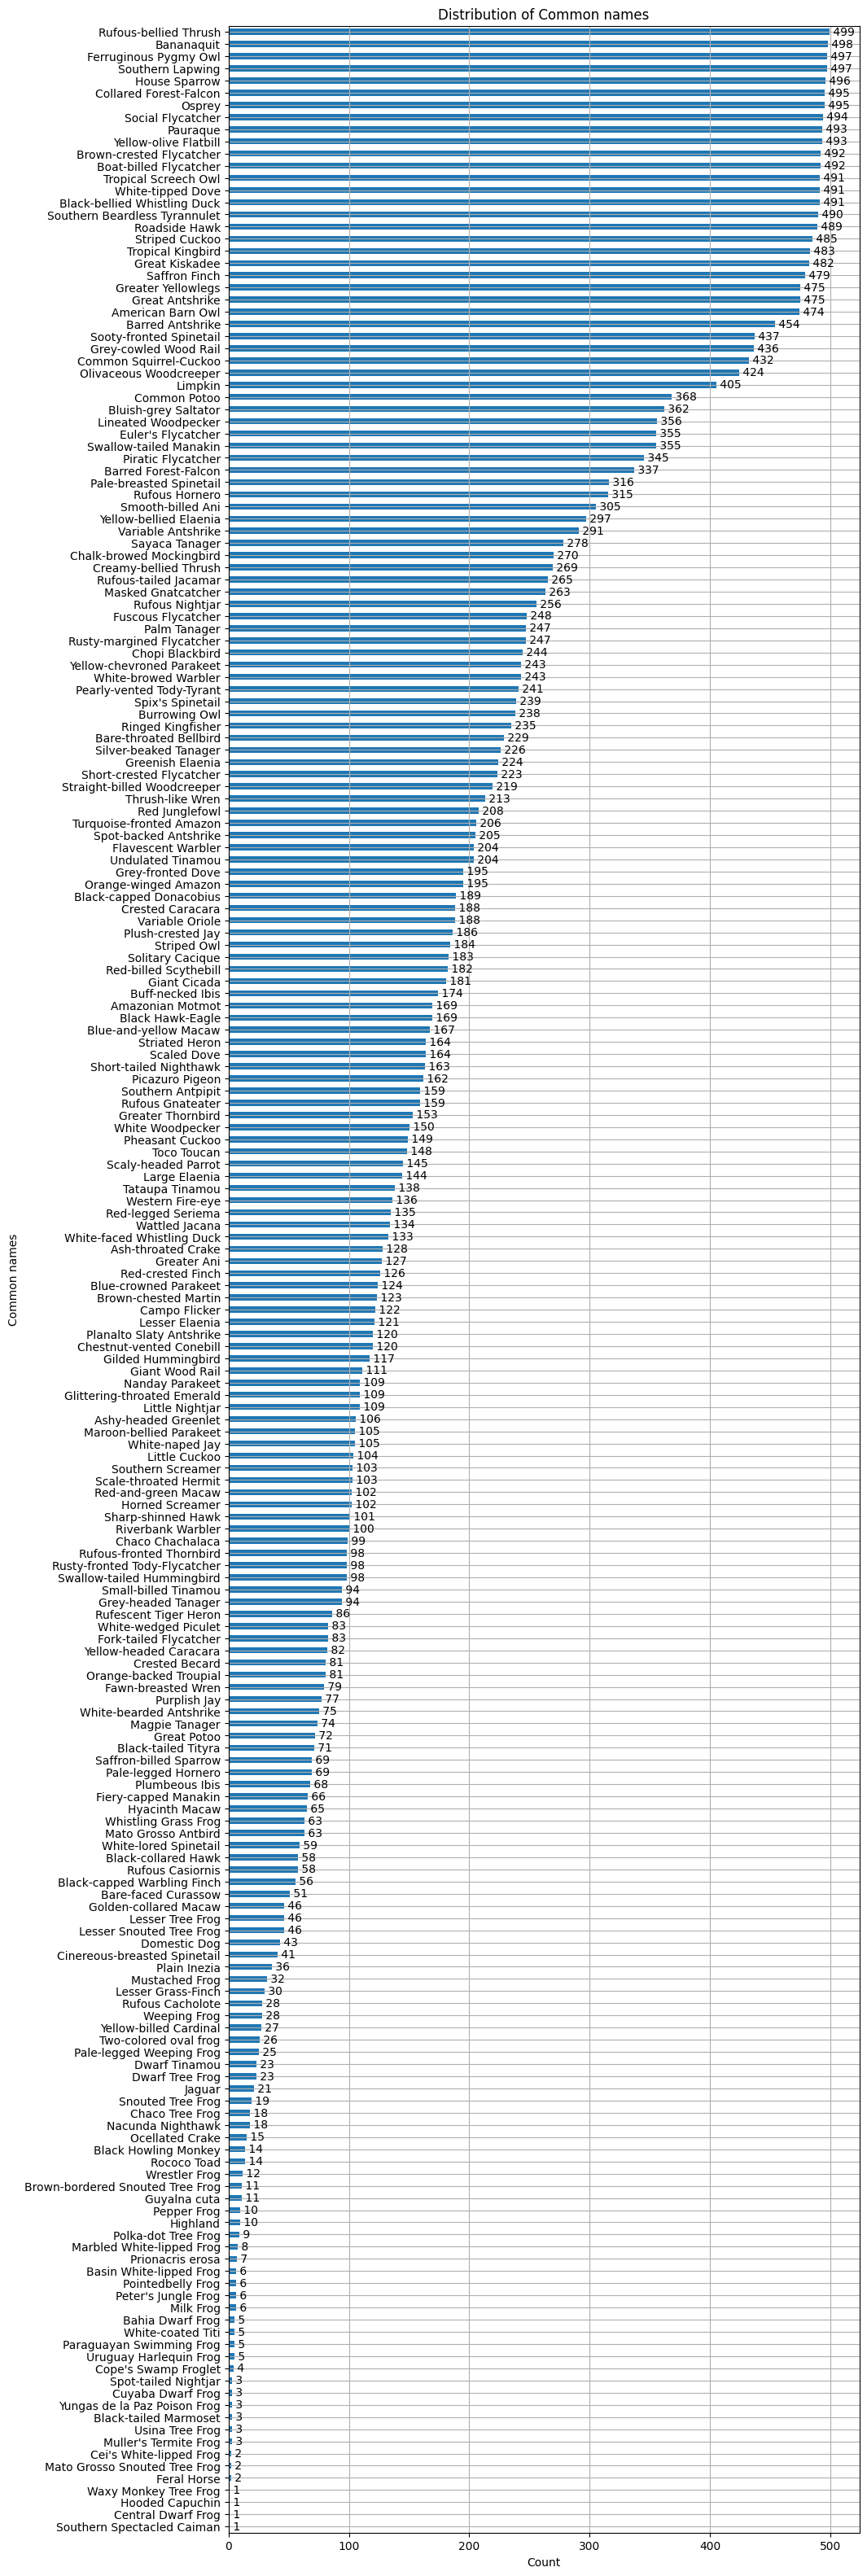

In [16]:
counts = train_cat['common_name'].value_counts(ascending=True)

fig, ax = plt.subplots(figsize=(10, 40))

counts.plot(kind='barh', ax=ax)

# Put count at the front/end of each bar
for i, v in enumerate(counts.values):
    ax.text(
        v,            # end of bar
        i,            # bar position
        f' {v}',      # count text
        va='center',
        ha='left'
    )

ax.set_xlabel('Count')
ax.set_ylabel('Common names')
ax.set_title('Distribution of Common names')

plt.grid(True)
plt.show()

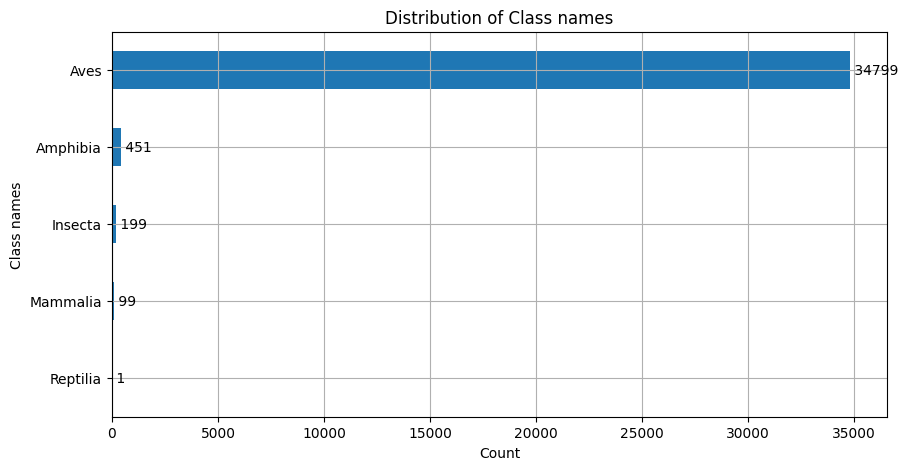

In [17]:
counts = train_cat['class_name'].value_counts(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

counts.plot(kind='barh', ax=ax)

# Put count at the front/end of each bar
for i, v in enumerate(counts.values):
    ax.text(
        v,            # end of bar
        i,            # bar position
        f' {v}',      # count text
        va='center',
        ha='left'
    )

ax.set_xlabel('Count')
ax.set_ylabel('Class names')
ax.set_title('Distribution of Class names')

plt.grid(True)
plt.show()

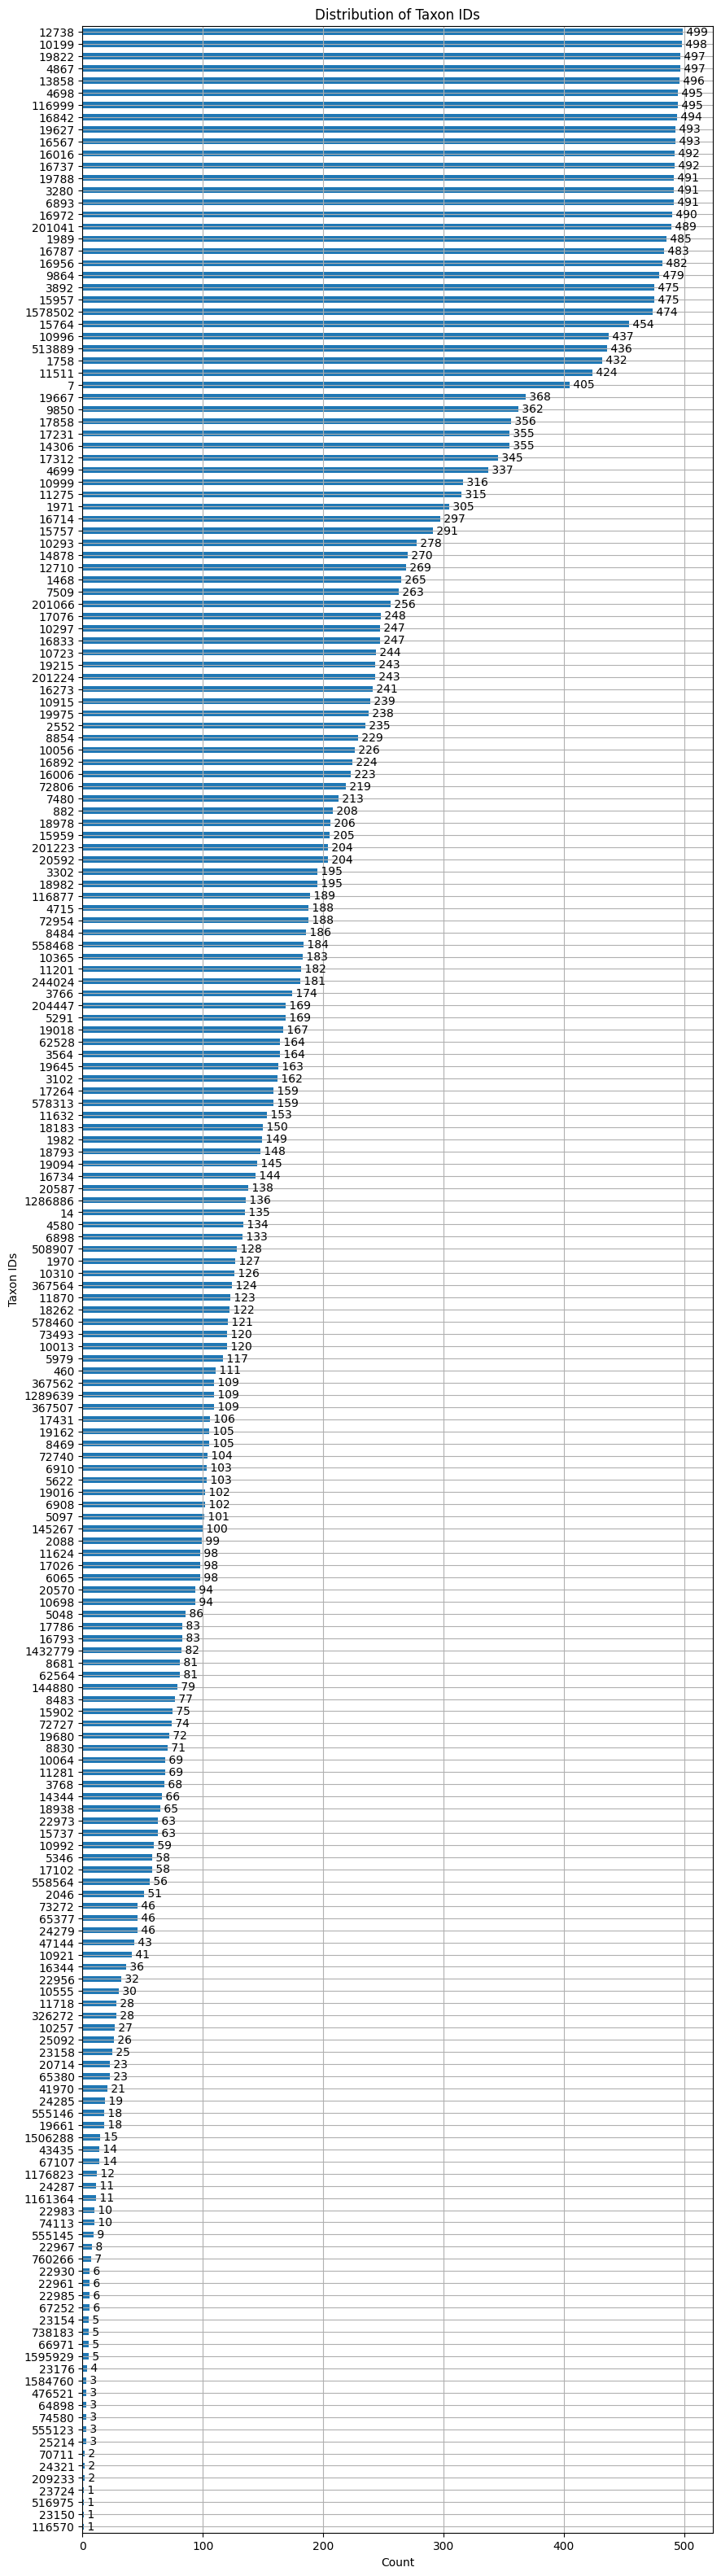

In [18]:
counts = train['inat_taxon_id'].value_counts(ascending=True)

fig, ax = plt.subplots(figsize=(10, 40))

counts.plot(kind='barh', ax=ax)

# Put count at the front/end of each bar
for i, v in enumerate(counts.values):
    ax.text(
        v,            # end of bar
        i,            # bar position
        f' {v}',      # count text
        va='center',
        ha='left'
    )

ax.set_xlabel('Count')
ax.set_ylabel('Taxon IDs')
ax.set_title('Distribution of Taxon IDs')

plt.grid(True)
plt.show()

<Axes: ylabel='collection'>

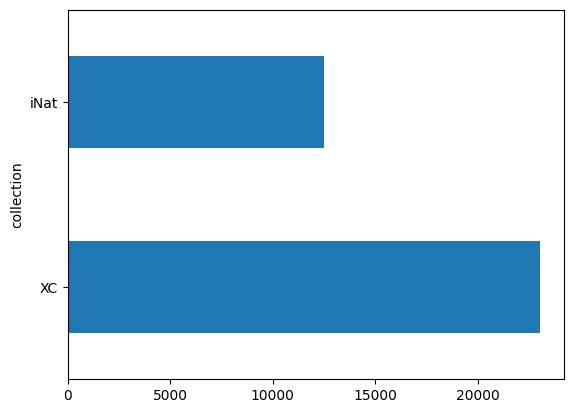

In [19]:
train['collection'].value_counts().plot(kind='barh')

### `train_soundscapes_labels.csv`

In [20]:
trs

,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380
...,...,...,...,...
1473,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:35,00:00:40,555146;65380
1474,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:40,00:00:45,517063;555146
1475,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:45,00:00:50,517063;555146
1476,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:50,00:00:55,517063;555146;66971


In [49]:
len(set(label for x in trs['primary_label'] for label in x.split(';')))

75

primary_label
22973;24321;517063;555146;65380;66971            2
1491113;22967;22973;24279;517063;65380;67252     2
22961;23158;517063;65377;65380                   2
22961;517063;65377;65380                         2
22961;65380                                      2
                                                ..
23158;24279;24321;555146;65380;66971            26
22973;517063;555146;65380                       28
517063                                          36
24321;555146;65380;66971                        36
23158;24279;24321;517063;555146;65380;66971     54
Name: count, Length: 251, dtype: int64


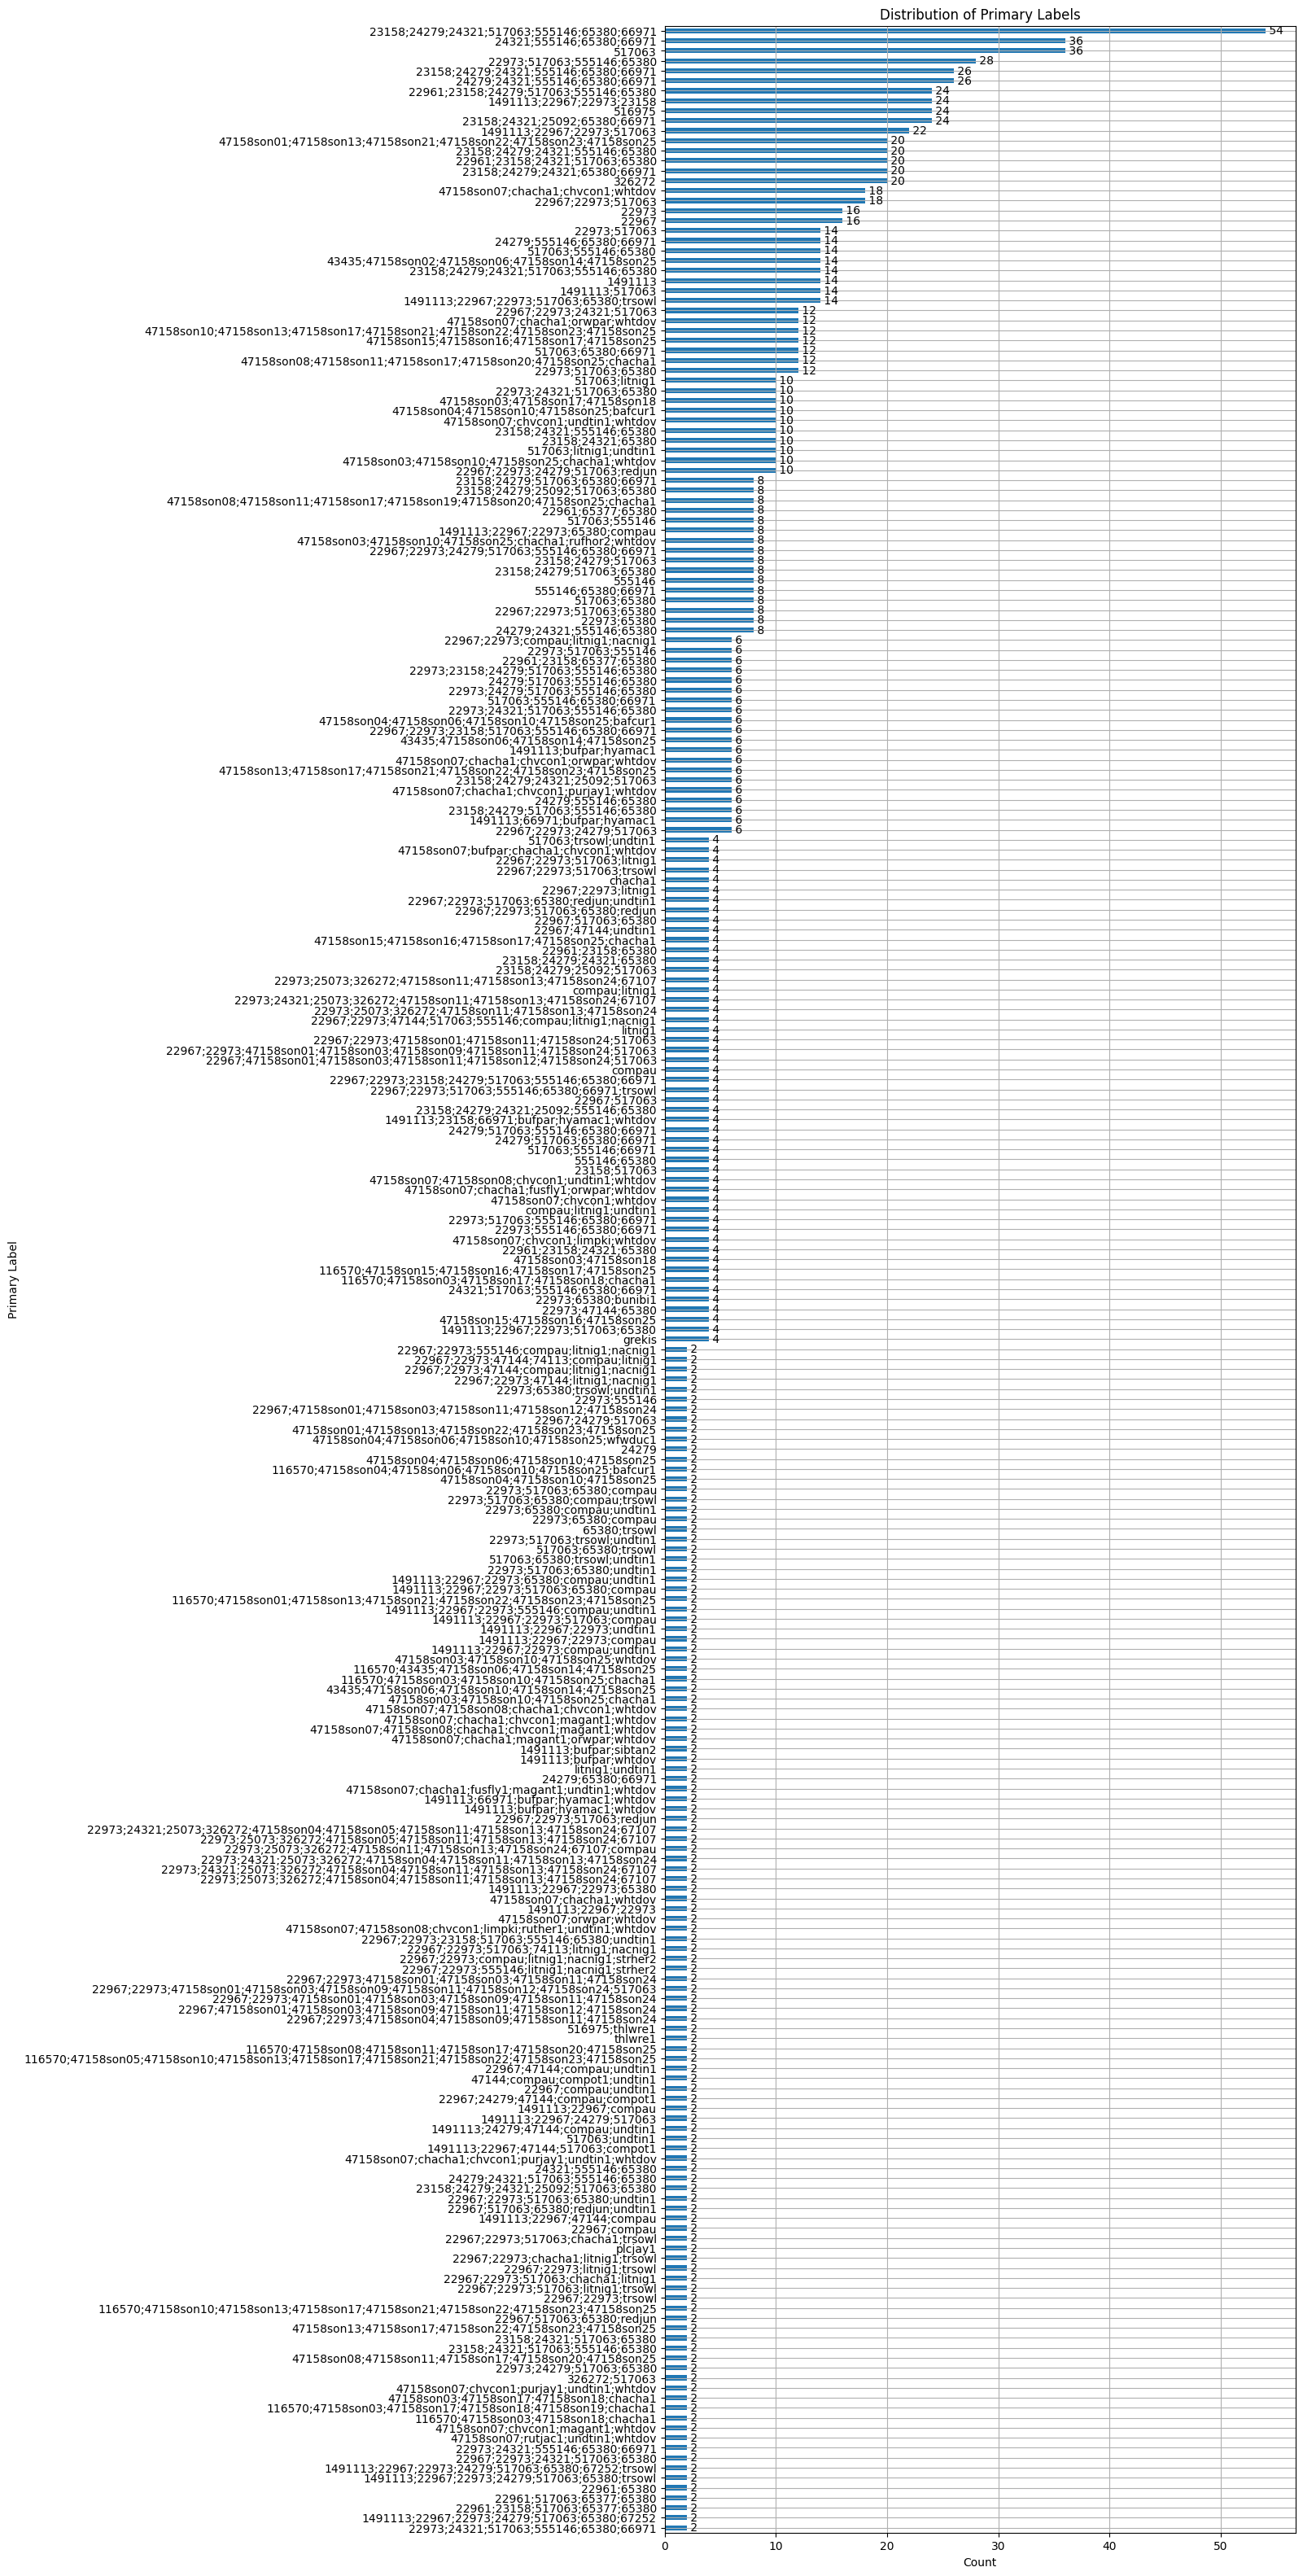

In [21]:
counts = trs['primary_label'].value_counts(ascending=True)

print(counts)

fig, ax = plt.subplots(figsize=(10, 40))

counts.plot(kind='barh', ax=ax)

# Put count at the front/end of each bar
for i, v in enumerate(counts.values):
    ax.text(
        v,            # end of bar
        i,            # bar position
        f' {v}',      # count text
        va='center',
        ha='left'
    )

ax.set_xlabel('Count')
ax.set_ylabel('Primary Label')
ax.set_title('Distribution of Primary Labels')

plt.grid(True)
plt.show()

In [22]:
trs['filename'].nunique()

66

In [23]:
print(f"Total 5s windows in soundscapes: {len(trs)}")

Total 5s windows in soundscapes: 1478


In [24]:
# Calculate number of labels per window
trs['num_labels'] = trs['primary_label'].fillna("").apply(lambda x: len(str(x).split(';')) if x != "" else 0)

print(f"Average species per window: {trs['num_labels'].mean():.2f}")
print(f"Max species in a window: {trs['num_labels'].max()}")
print(f"Windows with 0 labels: {(trs['num_labels'] == 0).sum()}")

Average species per window: 4.22
Max species in a window: 10
Windows with 0 labels: 0


In [26]:
# Explode the labels to see individual species frequency
exploded_soundscapes = trs.assign(
    label_id = trs['primary_label'].str.split(';')
).explode('label_id')

# Clean up empty strings
exploded_soundscapes = exploded_soundscapes[exploded_soundscapes['label_id'] != ""]

# Mapping Fix: Use 'primary_label' as key and ensure everything is string-typed
# This handles both alpha-numeric bird codes (e.g. 'bunibi1') and numeric frog/insect IDs
id_to_name = dict(zip(taxonomy['primary_label'].astype(str), taxonomy['common_name']))
exploded_soundscapes['common_name'] = exploded_soundscapes['label_id'].astype(str).map(id_to_name)

print(f"Total bird/taxa occurrences: {len(exploded_soundscapes)}")
print(f"\nTop 15 species in soundscapes:\n{exploded_soundscapes['common_name'].value_counts().head(15)}")

Total bird/taxa occurrences: 6244

Top 15 species in soundscapes:
common_name
Dwarf Tree Frog                     666
Southern Orange-legged Leaf Frog    626
Whistling Grass Frog                426
Chaco Tree Frog                     420
Pale-legged Weeping Frog            350
Lesser Snouted Tree Frog            346
Mato Grosso Snouted Tree Frog       344
Marbled White-lipped Frog           310
Paraguayan Swimming Frog            298
Insect sonotype25                   168
Guaraní leaf-litter frog            158
Chaco Chachalaca                    130
White-tipped Dove                   126
Insect sonotype07                    96
Undulated Tinamou                    86
Name: count, dtype: int64


> Note on Soundscape Label Encoding\nThe `primary_label` column in soundscapes uses a hybrid identification system:\n- **Birds** are usually identified by alpha-numeric codes (e.g., `bunibi1`).\n- **Other taxa** (frogs, insects) often use their numeric Taxon IDs.\n\nTo analyze these correctly, we must avoid forcing numeric conversion and map against the `primary_label` column in the taxonomy, ensuring both formats are treated as strings.

### `taxonomy.csv`

In [27]:
taxonomy

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia
...,...,...,...,...,...
229,yebela1,16714,Elaenia flavogaster,Yellow-bellied Elaenia,Aves
230,yecmac,73272,Primolius auricollis,Golden-collared Macaw,Aves
231,yecpar,19215,Brotogeris chiriri,Yellow-chevroned Parakeet,Aves
232,yehcar1,1432779,Daptrius chimachima,Yellow-headed Caracara,Aves


In [28]:
taxonomy[~taxonomy['primary_label'].isin(train['primary_label'])]

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
23,25073,25073,Chiasmocleis mehelyi,Chiasmocleis mehelyi,Amphibia
30,47158son01,47158,Insect son01,Insect sonotype01,Insecta
31,47158son02,47158,Insect son02,Insect sonotype02,Insecta
32,47158son03,47158,Insect son03,Insect sonotype03,Insecta
33,47158son04,47158,Insect son04,Insect sonotype04,Insecta
34,47158son05,47158,Insect son05,Insect sonotype05,Insecta
35,47158son06,47158,Insect son06,Insect sonotype06,Insecta
36,47158son07,47158,Insect son07,Insect sonotype07,Insecta
37,47158son08,47158,Insect son08,Insect sonotype08,Insecta


In [47]:
len(taxonomy[~taxonomy['primary_label'].isin(train['primary_label'])])

28

In [30]:
taxonomy['class_name'].value_counts()

class_name
Aves        162
Amphibia     35
Insecta      28
Mammalia      8
Reptilia      1
Name: count, dtype: int64

### `sample_submission.csv`

In [34]:
ss

,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2026_Test_0001_S05_20250227_010002_10,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
2,BC2026_Test_0001_S05_20250227_010002_15,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274


In [43]:
ss_T = ss.set_index('row_id').T.rename_axis('row_id').reset_index().rename_axis(None, axis=1)
ss_T

,row_id,BC2026_Test_0001_S05_20250227_010002_5,BC2026_Test_0001_S05_20250227_010002_10,BC2026_Test_0001_S05_20250227_010002_15
0,1161364,0.004274,0.004274,0.004274
1,116570,0.004274,0.004274,0.004274
2,1176823,0.004274,0.004274,0.004274
3,1491113,0.004274,0.004274,0.004274
4,1595929,0.004274,0.004274,0.004274
...,...,...,...,...
229,yebela1,0.004274,0.004274,0.004274
230,yecmac,0.004274,0.004274,0.004274
231,yecpar,0.004274,0.004274,0.004274
232,yehcar1,0.004274,0.004274,0.004274


In [45]:
ss_T[~ss_T['row_id'].isin(train['primary_label'])]

,row_id,BC2026_Test_0001_S05_20250227_010002_5,BC2026_Test_0001_S05_20250227_010002_10,BC2026_Test_0001_S05_20250227_010002_15
3,1491113,0.004274,0.004274,0.004274
23,25073,0.004274,0.004274,0.004274
30,47158son01,0.004274,0.004274,0.004274
31,47158son02,0.004274,0.004274,0.004274
32,47158son03,0.004274,0.004274,0.004274
33,47158son04,0.004274,0.004274,0.004274
34,47158son05,0.004274,0.004274,0.004274
35,47158son06,0.004274,0.004274,0.004274
36,47158son07,0.004274,0.004274,0.004274
37,47158son08,0.004274,0.004274,0.004274


In [46]:
len(ss_T[~ss_T['row_id'].isin(train['primary_label'])])

28

# Audio File Inventory & Structure

### 1. `train_audio` Directory Analysis

In [29]:
species_dirs = [d for d in TRAIN_AUDIO_DIR.iterdir() if d.is_dir()]
species_audio_count = {}
total_audio_files = 0
audio_extensions = defaultdict(int)

for species_dir in sorted(species_dirs):
    audio_files = list(species_dir.glob("*.ogg"))
    species_audio_count[species_dir.name] = len(audio_files)
    total_audio_files += len(audio_files)
    for f in audio_files:
        audio_extensions[f.suffix] += 1

print(f"Total species directories: {len(species_dirs)}")
print(f"Total audio files in train_audio: {total_audio_files}")
print(f"Audio file formats: {dict(audio_extensions)}")

Total species directories: 206
Total audio files in train_audio: 35549
Audio file formats: {'.ogg': 35549}


### 2. Species-level Statistics

In [30]:
audio_per_species = list(species_audio_count.values())
print(f"Audio files per species:")
print(f"  - Mean: {np.mean(audio_per_species):.1f}")
print(f"  - Median: {np.median(audio_per_species):.1f}")
print(f"  - Std Dev: {np.std(audio_per_species):.1f}")
print(f"  - Min: {np.min(audio_per_species)}")
print(f"  - Max: {np.max(audio_per_species)}")

# Top and bottom species
print(f"\nTop 10 species by audio count:")
top_species = sorted(species_audio_count.items(), key=lambda x: x[1], reverse=True)[:10]
for species, count in top_species:
    print(f"  {species:20s}: {count:4d} files")

print(f"\nBottom 10 species by audio count:")
bottom_species = sorted(species_audio_count.items(), key=lambda x: x[1])[:10]
for species, count in bottom_species:
    print(f"  {species:20s}: {count:4d} files")

Audio files per species:
  - Mean: 172.6
  - Median: 125.0
  - Std Dev: 155.0
  - Min: 1
  - Max: 499

Top 10 species by audio count:
  rubthr1             :  499 files
  banana              :  498 files
  fepowl              :  497 files
  soulap1             :  497 files
  houspa              :  496 files
  coffal1             :  495 files
  osprey              :  495 files
  socfly1             :  494 files
  compau              :  493 files
  yeofly1             :  493 files

Bottom 10 species by audio count:
  116570              :    1 files
  23150               :    1 files
  23724               :    1 files
  516975              :    1 files
  209233              :    2 files
  24321               :    2 files
  70711               :    2 files
  25214               :    3 files
  476521              :    3 files
  555123              :    3 files


### 3. Soundscapes Inventory

In [31]:
print("1. TRAIN SOUNDSCAPES")
soundscape_files = list(TRAIN_SOUNDSCAPES_DIR.glob("*.ogg"))
print(f"Total soundscape files: {len(soundscape_files)}")

print("\n2. TEST SOUNDSCAPES")
test_soundscape_files = list(TEST_SOUNDSCAPES_DIR.glob("*.ogg"))
print(f"Total test soundscape files: {len(test_soundscape_files)}")

1. TRAIN SOUNDSCAPES
Total soundscape files: 10658

2. TEST SOUNDSCAPES
Total test soundscape files: 0


### 4. Storage & Size Analysis

In [32]:
train_audio_size = sum(f.stat().st_size for f in TRAIN_AUDIO_DIR.rglob("*.ogg"))
soundscape_size = sum(f.stat().st_size for f in soundscape_files)

print(f"Total size (train_audio): {train_audio_size / 1e9:.2f} GB")
print(f"Avg train_audio file size: {train_audio_size / total_audio_files / 1e6:.2f} MB")
print(f"Total size (train_soundscapes): {soundscape_size / 1e9:.2f} GB")
print(f"Avg soundscape file size: {soundscape_size / max(1, len(soundscape_files)) / 1e6:.2f} MB")

Total size (train_audio): 10.75 GB
Avg train_audio file size: 0.30 MB
Total size (train_soundscapes): 5.38 GB
Avg soundscape file size: 0.50 MB


### 5. Detailed Audio Properties (Sampling)

In [33]:
np.random.seed(42)
sample_size = 100
all_train_audio_files = list(TRAIN_AUDIO_DIR.rglob("*.ogg"))
sample_train_audio = np.random.choice(all_train_audio_files, min(sample_size, len(all_train_audio_files)), replace=False)

audio_properties = {'filename': [], 'duration_seconds': [], 'sample_rate': [], 'channels': [], 'n_frames': []}

print(f"Analyzing {len(sample_train_audio)} random train audio files...")
for audio_file in tqdm(sample_train_audio, desc='Train audio samples'):
    try:
        info = sf.info(str(audio_file))
        audio_properties['filename'].append(audio_file.name)
        audio_properties['duration_seconds'].append(info.duration)
        audio_properties['sample_rate'].append(info.samplerate)
        audio_properties['channels'].append(info.channels)
        audio_properties['n_frames'].append(info.frames)
    except Exception as e:
        continue

audio_props_df = pd.DataFrame(audio_properties)
print(audio_props_df[['duration_seconds', 'sample_rate', 'channels']].describe())

Analyzing 100 random train audio files...


Train audio samples: 100%|██████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 622.15it/s]

       duration_seconds  sample_rate  channels
count        100.000000        100.0     100.0
mean          39.769722      32000.0       1.0
std           57.898193          0.0       0.0
min            4.440000      32000.0       1.0
25%           13.116406      32000.0       1.0
50%           24.727484      32000.0       1.0
75%           42.456375      32000.0       1.0
max          471.480000      32000.0       1.0


In [34]:
print(f"Analyzing {min(50, len(soundscape_files))} soundscape files...")
soundscape_properties = {'filename': [], 'duration_seconds': [], 'sample_rate': [], 'channels': []}

for audio_file in tqdm(soundscape_files[:50], desc='Soundscape samples'):
    try:
        info = sf.info(str(audio_file))
        soundscape_properties['filename'].append(audio_file.name)
        soundscape_properties['duration_seconds'].append(info.duration)
        soundscape_properties['sample_rate'].append(info.samplerate)
        soundscape_properties['channels'].append(info.channels)
    except Exception as e:
        continue

soundscape_props_df = pd.DataFrame(soundscape_properties)
print(soundscape_props_df[['duration_seconds', 'sample_rate', 'channels']].describe())

Analyzing 50 soundscape files...


Soundscape samples: 100%|█████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 535.41it/s]

       duration_seconds  sample_rate  channels
count              50.0         50.0      50.0
mean               60.0      32000.0       1.0
std                 0.0          0.0       0.0
min                60.0      32000.0       1.0
25%                60.0      32000.0       1.0
50%                60.0      32000.0       1.0
75%                60.0      32000.0       1.0
max                60.0      32000.0       1.0
